In [1]:
print("welcome boss")

welcome boss


In [2]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

In [57]:
df=pd.read_csv('student_placement_dataset_5000.csv')

In [58]:
df.shape

(5000, 10)

In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student_ID         5000 non-null   int64  
 1   Gender             5000 non-null   str    
 2   Age                5000 non-null   int64  
 3   Branch             5000 non-null   str    
 4   CGPA               5000 non-null   float64
 5   10th_Percentage    5000 non-null   float64
 6   12th_Percentage    5000 non-null   float64
 7   No_of_Internships  5000 non-null   int64  
 8   No_of_Projects     5000 non-null   int64  
 9   Placed             5000 non-null   str    
dtypes: float64(3), int64(4), str(3)
memory usage: 390.8 KB


In [60]:
df.head(3)

,Student_ID,Gender,Age,Branch,CGPA,10th_Percentage,12th_Percentage,No_of_Internships,No_of_Projects,Placed
0,1001,Female,20,ME,5.00,62.00,54.51,2,4,No
1,1002,Male,20,CSE,5.58,74.76,65.24,2,4,Yes
2,1003,Female,20,ME,5.00,57.82,55.43,0,5,No


In [61]:
X = df[['Branch', 'CGPA', 'No_of_Internships', 'No_of_Projects']]

In [62]:
y = df['Placed']

In [63]:
X.head()

,Branch,CGPA,No_of_Internships,No_of_Projects
0,ME,5.00,2,4
1,CSE,5.58,2,4
2,ME,5.00,0,5
3,ME,7.92,1,8
4,EE,8.81,0,2


In [64]:
y.head()

0     No
1    Yes
2     No
3    Yes
4    Yes
Name: Placed, dtype: str

In [65]:
X["Branch"].unique()

<StringArray>
['ME', 'CSE', 'EE', 'ECE', 'CE', 'IT']
Length: 6, dtype: str

In [66]:
y.unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

ONE HOT ENCODING  string 0s and 1s it becomes [0,1,0,0,0]

In [ ]:
%%sql


LABEL ENCODING STRING 0 1 2 3 4 5 ....

In [67]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

encoder=LabelEncoder()
X["Branch"]=encoder.fit_transform(X["Branch"])

In [68]:
encoder.classes_

array(['CE', 'CSE', 'ECE', 'EE', 'IT', 'ME'], dtype=object)

In [69]:
X.head()

,Branch,CGPA,No_of_Internships,No_of_Projects
0,5,5.00,2,4
1,1,5.58,2,4
2,5,5.00,0,5
3,5,7.92,1,8
4,3,8.81,0,2


In [87]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

In [88]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df['Placed'])

print(target_encoder.classes_)

['No' 'Yes']


In [89]:
from sklearn.model_selection import train_test_split

In [90]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

In [91]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(random_state = 42)

In [92]:
model.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [93]:
model.score(X_test,y_test)*100

90.2

In [94]:
y_pred = model.predict(X_test)

In [95]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.83      0.84       313
           1       0.92      0.93      0.93       687

    accuracy                           0.90      1000
   macro avg       0.89      0.88      0.89      1000
weighted avg       0.90      0.90      0.90      1000



In [96]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[261  52]
 [ 46 641]]


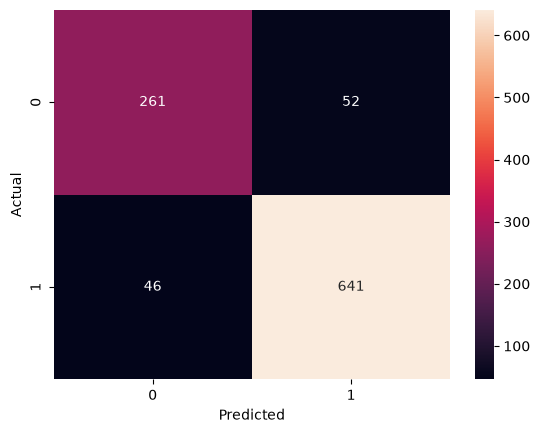

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [98]:
def predict_placement(branch, cgpa, internships, projects):

    branch_encoded = encoder.transform([branch])[0]

    input_data = pd.DataFrame([[
        branch_encoded,
        cgpa,
        internships,
        projects
    ]], columns=[
        'Branch',
        'CGPA',
        'No_of_Internships',
        'No_of_Projects'
    ])

    prediction = model.predict(input_data)[0]

    result = target_encoder.inverse_transform([prediction])[0]

    return result

In [99]:
result = predict_placement("CSE", 8.5, 2, 3)
print("Placed:", result)

Placed: Yes


In [100]:
import joblib

joblib.dump(model, "placement_model.pkl")
joblib.dump(encoder, "branch_encoder.pkl")
joblib.dump(target_encoder, "target_encoder.pkl")

['target_encoder.pkl']

In [101]:
import os

print(os.listdir())

['branch_encoder.pkl', 'placement.ipynb', 'placement_model.pkl', 'student_placement_dataset_5000.csv', 'target_encoder.pkl']
